# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [15]:
# Replace None with your code
# Imports
import sqlite3
import pandas as pd


# Create connection to database
conn = sqlite3.connect('data.sqlite')

### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.
*Hint*: Make sure creditLimit is numeric.

In [16]:
# Replace None with your code

pd.read_sql("""
SELECT DISTINCT state
FROM customers
""", conn)#checking for unique values to identify how califonia is written, which is CA
df = pd.read_sql("""
SELECT *
FROM customers
WHERE state = 'CA'
  AND CAST(creditLimit AS REAL) > 25000
""", conn)# customers based in califonia with a credit limit of 25,000 in numeric

df




,customerNumber,customerName,contactLastName,contactFirstName,phone,addressLine1,addressLine2,city,state,postalCode,country,salesRepEmployeeNumber,creditLimit
0,124,Mini Gifts Distributors Ltd.,Nelson,Susan,4155551450,5677 Strong St.,,San Rafael,CA,97562,USA,1165,210500.00
1,129,Mini Wheels Co.,Murphy,Julie,6505555787,5557 North Pendale Street,,San Francisco,CA,94217,USA,1165,64600.00
2,161,Technics Stores Inc.,Hashimoto,Juri,6505556809,9408 Furth Circle,,Burlingame,CA,94217,USA,1165,84600.00
3,205,Toys4GrownUps.com,Young,Julie,6265557265,78934 Hillside Dr.,,Pasadena,CA,90003,USA,1166,90700.00
4,239,Collectable Mini Designs Co.,Thompson,Valarie,7605558146,361 Furth Circle,,San Diego,CA,91217,USA,1166,105000.00
5,321,Corporate Gift Ideas Co.,Brown,Julie,6505551386,7734 Strong St.,,San Francisco,CA,94217,USA,1165,105000.00
6,347,"Men 'R' US Retailers, Ltd.",Chandler,Brian,2155554369,6047 Douglas Av.,,Los Angeles,CA,91003,USA,1166,57700.00
7,450,The Sharp Gifts Warehouse,Frick,Sue,4085553659,3086 Ingle Ln.,,San Jose,CA,94217,USA,1165,77600.00
8,475,West Coast Collectables Co.,Thompson,Steve,3105553722,3675 Furth Circle,,Burbank,CA,94019,USA,1166,55400.00
9,487,Signal Collectibles Ltd.,Taylor,Sue,4155554312,2793 Furth Circle,,Brisbane,CA,94217,USA,1165,60300.00


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [17]:
# Replace None with your code
query = """
SELECT *
FROM customers
WHERE country != 'USA'
  AND customerName LIKE '%Collect%'
"""

df = pd.read_sql(query, conn)#finding non USA customers who have collect in their name
df

,customerNumber,customerName,contactLastName,contactFirstName,phone,addressLine1,addressLine2,city,state,postalCode,country,salesRepEmployeeNumber,creditLimit
0,114,"Australian Collectors, Co.",Ferguson,Peter,03 9520 4555,636 St Kilda Road,Level 3,Melbourne,Victoria,3004,Australia,1611,117300.00
1,189,"Clover Collections, Co.",Cassidy,Dean,+353 1862 1555,25 Maiden Lane,Floor No. 4,Dublin,,2,Ireland,1504,69400.00
2,201,"UK Collectables, Ltd.",Devon,Elizabeth,(171) 555-2282,"12, Berkeley Gardens Blvd",,Liverpool,,WX1 6LT,UK,1501,92700.00
3,211,"King Kong Collectables, Co.",Gao,Mike,+852 2251 1555,Bank of China Tower,1 Garden Road,Central Hong Kong,,,Hong Kong,1621,58600.00
4,227,Heintze Collectables,Ibsen,Palle,86 21 3555,Smagsloget 45,,Århus,,8200,Denmark,1401,120800.00
5,260,"Royal Canadian Collectables, Ltd.",Lincoln,Elizabeth,(604) 555-4555,23 Tsawassen Blvd.,,Tsawassen,BC,T2F 8M4,Canada,1323,89600.00
6,293,BG&E Collectables,Harrison,Ed,+41 26 425 50 01,Rte des Arsenaux 41,,Fribourg,,1700,Switzerland,,0.00
7,353,Reims Collectables,Henriot,Paul,26.47.1555,59 rue de l'Abbaye,,Reims,,51100,France,1337,81100.00
8,376,Precious Collectables,Urs,Braun,0452-076555,Hauptstr. 29,,Bern,,3012,Switzerland,1702,0.00
9,382,Salzburg Collectables,Pipps,Georg,6562-9555,Geislweg 14,,Salzburg,,5020,Austria,1401,71700.00


## Reflection Question:
I used select * from customers to select every customer in the customer column,and then filter,like choose only customers from other countries that is not USA,then used %Collect% to enable  search within the name field for a specific keyword, no matter where it appears, rather than requiring the name to match exactly.

## Type your answer in markdown here!

### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [18]:
# Replace None with your code
query = """
SELECT state, AVG(CAST(creditLimit AS REAL)) AS avgCreditLimit
FROM customers 
WHERE country = 'USA'
GROUP BY state
"""

df = pd.read_sql(query, conn)#finding which avarage belong to which state in USA
df

,state,avgCreditLimit
0,CA,83854.545455
1,CT,57350.000000
2,MA,70755.555556
3,NH,114200.000000
4,NJ,43000.000000
5,NV,71800.000000
6,NY,89966.666667
7,PA,84766.666667


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

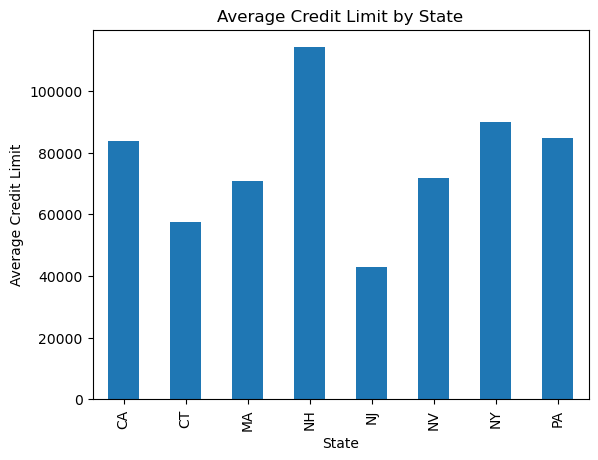

In [19]:
# Replace None with your visual code
# Produce a visual to represent the average credit limit by state
import matplotlib.pyplot as plt
df.plot(kind='bar', x='state', y='avgCreditLimit', legend=False)
plt.title('Average Credit Limit by State')
plt.xlabel('State')
plt.ylabel('Average Credit Limit')#we use bar graph for categorical and numerical bivariate analysis
plt.show() #Producing a visual to represent the average credit limit by state , NH has the highest credit limit

### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [20]:
# Replace None with your code
query = """
SELECT customers.customerName, SUM(payments.amount) AS totalPayments
FROM payments
JOIN customers ON payments.customerNumber = customers.customerNumber
GROUP BY customers.customerName
ORDER BY totalPayments DESC
LIMIT 10
"""

df = pd.read_sql(query, conn)#geting the top 10 customers by finding the total payments per customer
df

,customerName,totalPayments
0,Euro+ Shopping Channel,715738.98
1,Mini Gifts Distributors Ltd.,584188.24
2,"Australian Collectors, Co.",180585.07
3,Muscle Machine Inc,177913.95
4,"Dragon Souveniers, Ltd.",156251.03
5,"Down Under Souveniers, Inc",154622.08
6,"AV Stores, Co.",148410.09
7,"Anna's Decorations, Ltd",137034.22
8,Corporate Gift Ideas Co.,132340.78
9,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

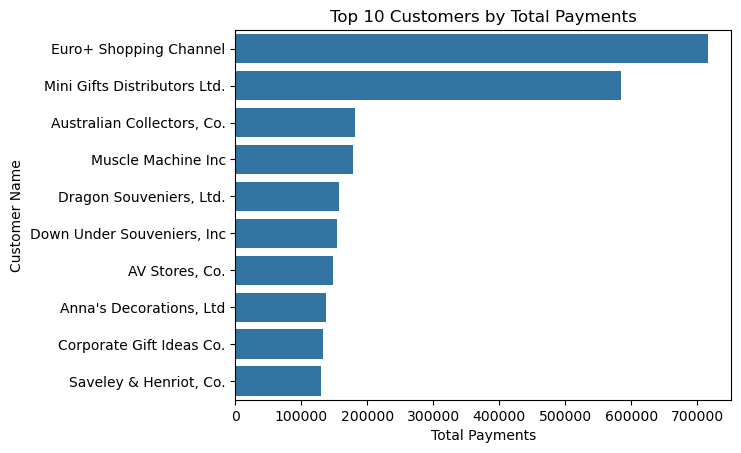

In [21]:
# Replace None with your visual code
# Produce a visual to represent the top ten customers in terms of total payments
import seaborn as sns

sns.barplot(data=df, x='totalPayments', y='customerName')
plt.title("Top 10 Customers by Total Payments")
plt.xlabel("Total Payments")
plt.ylabel("Customer Name")# visualizing the first 10 customers with the best/highest payment and Euro+Shopping
plt.show()#has the highest total payments

### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [22]:
# Replace None with you code
query = """
SELECT customers.customerName, products.productName, SUM(orderdetails.quantityOrdered) AS totalQuantity
FROM customers
JOIN orders ON customers.customerNumber = orders.customerNumber
JOIN orderdetails ON orders.orderNumber = orderdetails.orderNumber
JOIN products ON orderdetails.productCode = products.productCode
GROUP BY customers.customerName, products.productName
HAVING totalQuantity >= 10
ORDER BY totalQuantity
"""

df = pd.read_sql(query, conn)#checking the popular data by finding a product bought 10 times or more per customer
                                   #while arranging the aanalysis in asc order
df

,customerName,productName,totalQuantity
0,"Extreme Desk Decorations, Ltd",1961 Chevrolet Impala,10
1,Petit Auto,1913 Ford Model T Speedster,10
2,La Rochelle Gifts,1954 Greyhound Scenicruiser,11
3,Tekni Collectables Inc.,American Airlines: B767-300,11
4,The Sharp Gifts Warehouse,1969 Chevrolet Camaro Z28,13
...,...,...,...
2526,Euro+ Shopping Channel,2002 Chevy Corvette,174
2527,Euro+ Shopping Channel,1957 Chevy Pickup,183
2528,Euro+ Shopping Channel,1970 Dodge Coronet,197
2529,Euro+ Shopping Channel,1958 Chevy Corvette Limited Edition,245


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [23]:
# Replace None with your code
query = """
SELECT products.productLine,
       COUNT(DISTINCT products.productCode) AS numProducts,
       SUM(orderdetails.quantityOrdered) AS totalQuantityOrdered
FROM products
JOIN orderdetails ON products.productCode = orderdetails.productCode
GROUP BY products.productLine
"""

df = pd.read_sql(query, conn)#finding the total quanity oredered per product line and the total number
                             #of products that exist per line
df

,productLine,numProducts,totalQuantityOrdered
0,Classic Cars,37,35582
1,Motorcycles,13,12778
2,Planes,12,11872
3,Ships,9,8532
4,Trains,3,2818
5,Trucks and Buses,11,11001
6,Vintage Cars,24,22933


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

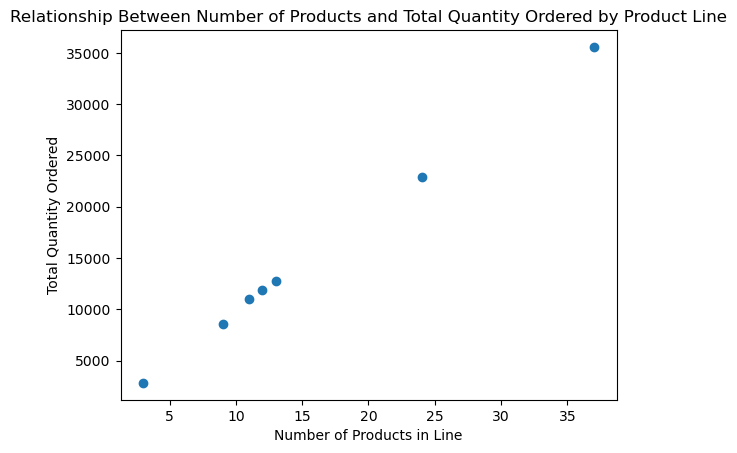

In [24]:
# Replace None with your visual code
# Produce a visual to represent the the relation between number of products and the total amount ordered
import matplotlib.pyplot as plt

plt.scatter(df['numProducts'], df['totalQuantityOrdered'])
plt.title('Relationship Between Number of Products and Total Quantity Ordered by Product Line')
plt.xlabel('Number of Products in Line')
plt.ylabel('Total Quantity Ordered')#scatter plot is good for showing relationship between numerical variables
plt.show()#hence having more products in a line correlates with higher total orders

## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

## Type your answer in markdown here!

### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [25]:
# Replace None with your code
query = """
SELECT employees.firstName, employees.lastName, employees.jobTitle, employees.reportsTo
FROM employees
WHERE employees.officeCode IN (
    SELECT offices.officeCode
    FROM offices
    JOIN employees ON offices.officeCode = employees.officeCode
    GROUP BY offices.officeCode
    HAVING COUNT(employees.employeeNumber) < 5
)
"""

df = pd.read_sql(query, conn)#identifying offices with fewer than 5 employees, then select employees details
df


,firstName,lastName,jobTitle,reportsTo
0,William,Patterson,Sales Manager (APAC),1056
1,Julie,Firrelli,Sales Rep,1143
2,Steve,Patterson,Sales Rep,1143
3,Foon Yue,Tseng,Sales Rep,1143
4,George,Vanauf,Sales Rep,1143
5,Larry,Bott,Sales Rep,1102
6,Barry,Jones,Sales Rep,1102
7,Andy,Fixter,Sales Rep,1088
8,Peter,Marsh,Sales Rep,1088
9,Tom,King,Sales Rep,1088


## Reflection Question:

I use the subquery to go through every office and give me only offices with less that 5 employees,from the codes provided ,I try to get the employees names and their job titles
## Type your answer in markdown here!

### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [26]:
# Replace None with your code
conn.close()#to close connection

### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [27]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

count    66236.000000
mean        94.654040
std        208.574111
min          3.000000
25%         81.000000
50%         91.000000
75%        104.000000
max      51420.000000
Name: runtime_minutes, dtype: float64

Correlation between runtime and rating: -0.006963469265964075


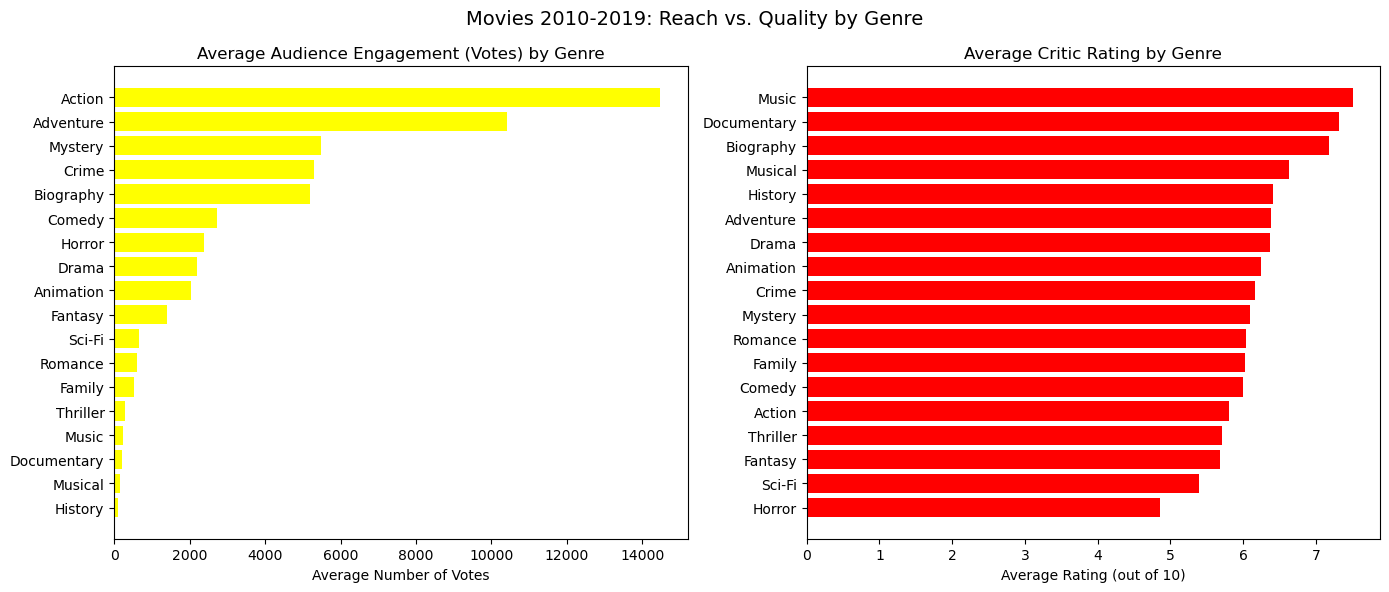

In [28]:
# Begin your code here


#checking how many movies per start_year?
year_counts = pd.read_sql("""
SELECT start_year, COUNT(*) AS num_movies
FROM movie_basics
GROUP BY start_year
ORDER BY start_year
""", conn4)
year_counts
#there are 9 years with number of moviees out of our required range ,theere is also an invalid year 
#2115,heence we have to eclude these years
#we have to only get the total number of movies within 2010 to 2019
coverage = pd.read_sql("""
SELECT
    (SELECT COUNT(*) FROM movie_basics WHERE start_year BETWEEN 2010 AND 2019) AS total_movies,
    (SELECT COUNT(*) 
       FROM movie_basics mb 
       JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
      WHERE mb.start_year BETWEEN 2010 AND 2019) AS movies_with_ratings
""", conn4)
coverage
#There are 1455081 total movies with 73856 total movies with ratings
#exploring genre level pattern,the ratings vs votes
genre_query = """
SELECT mb.genres, mr.averagerating, mr.numvotes
FROM movie_basics mb
JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
WHERE mb.start_year BETWEEN 2010 AND 2019
  AND mb.genres IS NOT NULL
"""
genre_df = pd.read_sql(genre_query, conn4)
genre_df['primary_genre'] = genre_df['genres'].apply(lambda g: g.split(',')[0])

genre_stats = (
    genre_df.groupby('primary_genre')
    .agg(num_movies=('averagerating', 'count'),
         avg_rating=('averagerating', 'mean'),
         avg_votes=('numvotes', 'mean'))
    .query('num_movies >= 100')
    .sort_values('num_movies', ascending=False)
)
genre_stats
#when comparing documentary and action movie, we see that documentary has the highest number of movies produced of 13962,
# but lower number of votes of 213.04 and rating of 7.32 compared
#to action with a rating of 5.81,number of movies produces 6988 but with the highest number of human votes of 14476.49

#checking if the genre pattern is stable or changes over time
trend_df = pd.read_sql("""
SELECT start_year, genres
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2019 AND genres IS NOT NULL
""", conn4)
trend_df['primary_genre'] = trend_df['genres'].apply(lambda g: g.split(',')[0])

trend = (
    trend_df[trend_df['primary_genre'].isin(['Action', 'Documentary', 'Drama', 'Comedy'])]
    .groupby(['start_year', 'primary_genre'])
    .size()
    .unstack()
)
trend
# looking at my key varible columns I Documentary production increases steadily before dropping at the start year 2019
#The same also affects the Action production

#checking for relaionship between runtime and ratings
runtime_df = pd.read_sql("""
SELECT mb.runtime_minutes, mr.averagerating
FROM movie_basics mb
JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
WHERE mb.start_year BETWEEN 2010 AND 2019
  AND mb.runtime_minutes IS NOT NULL
""", conn4)
print(runtime_df['runtime_minutes'].describe())
print('\nCorrelation between runtime and rating:', runtime_df['runtime_minutes'].corr(runtime_df['averagerating']))
#we conclude that there is no linear relationship between runtime and ratings with a correlation of -0.00069

# Check for missing (null) values in the fields we care about
null_counts = pd.read_sql("""
SELECT
    SUM(CASE WHEN primary_title IS NULL THEN 1 ELSE 0 END) AS null_primary_title,
    SUM(CASE WHEN runtime_minutes IS NULL THEN 1 ELSE 0 END) AS null_runtime,
    SUM(CASE WHEN genres IS NULL THEN 1 ELSE 0 END) AS null_genres
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2019
""", conn4)
null_counts  #there are 0 null values in the primary title,307765 missing values in the run time and 5359 missing values
# in geenre

#Check how many movies list more than one genre 
multi_genre = pd.read_sql("""
SELECT
    COUNT(*) AS total_with_genre,
    SUM(CASE WHEN genres LIKE '%,%' THEN 1 ELSE 0 END) AS multi_genre_count
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2019 AND genres IS NOT NULL
""", conn4)
multi_genre['pct_multi_genre'] = (multi_genre['multi_genre_count'] / multi_genre['total_with_genre'] * 100).round(1)
multi_genre#about 40% movies list more than one genre

 #Check title standardization
 #  does each movie have same format of writing the title?
title_check = pd.read_sql("""
SELECT
    COUNT(DISTINCT movie_id) AS distinct_movies_with_akas,
    COUNT(*) AS total_aka_rows
FROM movie_akas
""", conn4)
title_check['avg_titles_per_movie'] = (title_check['total_aka_rows'] / title_check['distinct_movies_with_akas']).round(2)
title_check#yes same formatt but others have 3 to 4 words eg distinct_movies_with_akas

# Visualize the core finding
#  average rating vs. average audience engagement by genre
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sorted_by_votes = genre_stats.sort_values('avg_votes', ascending=True)
axes[0].barh(sorted_by_votes.index, sorted_by_votes['avg_votes'], color="yellow")
axes[0].set_title('Average Audience Engagement (Votes) by Genre')
axes[0].set_xlabel('Average Number of Votes')

sorted_by_rating = genre_stats.sort_values('avg_rating', ascending=True)
axes[1].barh(sorted_by_rating.index, sorted_by_rating['avg_rating'], color="red")
axes[1].set_title('Average Critic Rating by Genre')
axes[1].set_xlabel('Average Rating (out of 10)')

plt.suptitle('Movies 2010-2019: Reach vs. Quality by Genre', fontsize=14)
plt.tight_layout()
plt.savefig('genre_reach_vs_quality.png', dpi=150, bbox_inches='tight')
plt.show()
#I conclude that Action genre has the highest audience angagement(votes) while music and documentary genre
#are leading with the highest critic rating 
# 1. initial exploration;there are 9 years with number of movies out of our required range ,there is also an invalid year 
#2115,hence we have to exclude these years
#we have to only get the total number of movies within 2010 to 2019
#There are 1455081 total movies with 73856 total movies with ratings
#when comparing documentary and action movie, we see that documentary has the highest number of movies produced of 13962,
# but lower number of votes of 213.04 and high rating of 7.32 compared
#to action with a rating of 5.81,number of movies produces 6988 but with the highest number of human votes of 14476.49
# looking at my key varible columns  Documentary production increases steadily before dropping at the start year 2019
#The same also affects the Action production
#we conclude that there is no linear relationship between runtime and ratings with a correlation of -0.00069
## 2. bussiness question
#""""""Given a fixed production budget should a streaming company prioritized genre with high audience angagement
#like Action or genre with high ratings and low audience angagement like Ducumentary
#"""
## 3. data cleaning task
#I noticed an invalid year 2115
#there were outliers since there was no linear reelationship between runtime and ratings
#there were missing values,0 null values in the primary title,307765 missing values in the run time and 5359 missing values
# in genre
#Genres is stored as a comma separated string

